<a href="https://colab.research.google.com/github/carrisian/del-big-data-al-modelo-predictivo/blob/main/colab/Episodios%20de%20Calima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Atmosférico: Detección de Episodios de Calima (2016-2024)

Este cuaderno integra datos de **CAMS** y **ERA5-Land** para identificar intrusiones de polvo sahariano.
El modelo utiliza un **Índice Sintético de Calima** (Score 0-3) basado en tres pilares físicos:
1. **Masa de partículas (PM10):** Umbral superior a 60 µg/m³.
2. **Higrometría (Humedad):** Condiciones de aridez (umbral corregido por zona).
3. **Atenuación Radiativa (UV):** Bloqueo de radiación solar por aerosoles.

In [33]:
#@title 🔧 Configuración del Entorno y Carga de Datos { display-mode: "form" }
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

# Montaje de Drive y definición de rutas
if not os.path.isdir('/content/drive'):
    drive.mount('/content/drive')

PATH_BASE = "/content/drive/MyDrive/TFM_Profesorado/"
RUTA_OUTPUT = os.path.join(PATH_BASE, "Resultados_TFM_Final")
os.makedirs(RUTA_OUTPUT, exist_ok=True)

# Carga del Dataset consolidado
df = pd.read_parquet(f"{PATH_BASE}Murcia_Dataset_Completo_Global_3H.parquet")
df['time'] = pd.to_datetime(df['time'])
df['anio'] = df['time'].dt.year

# Filtro temporal (2016 - 2024)
df = df[(df['anio'] >= 2016) & (df['anio'] <= 2024)].copy()

print(f"✅ Datos cargados correctamente. Registros: {len(df)}")

✅ Datos cargados correctamente. Registros: 394560


### 2. Metodología: Índice Sintético
Definimos un evento de calima cuando se cumplen al menos 2 de las 3 condiciones físicas.
*
Nota: Se han aplicado umbrales de humedad diferenciados según la proximidad al litoral para evitar sesgos.
*

In [34]:
#@title 🧮 Cálculo del Índice Sintético de Calima { display-mode: "form" }
# "Seguro": si la columna Zona no existe, la crea.
costeras = ['Cartagena', 'San Javier', 'Mazarrón', 'Águilas', 'Torre-Pacheco']
df['Zona'] = df['Estacion'].apply(lambda x: 'Costa' if x in costeras else 'Interior')

def calcular_indice_calima(row):
    pm10 = 1 if row['PM10'] > 60 else 0
    h_lim = 60 if row['Zona'] == 'Costa' else 40
    hum = 1 if row['Hum'] < h_lim else 0
    uv = 1 if (row['UV_Cielo_Despejado'] - row['UV_Real']) > 1.5 else 0
    return pm10 + hum + uv

df['es_calima_sintetico'] = df.apply(calcular_indice_calima, axis=1) >= 2

# Agrupación estadística
resumen_anual = df[df['es_calima_sintetico'] == True].groupby(['anio', 'Estacion', 'Zona']).size().reset_index(name='Eventos_3H')
resumen_anual['Horas_Calima'] = resumen_anual['Eventos_3H'] * 3
resumen_anual.to_csv(os.path.join(RUTA_OUTPUT, "Tabla_Maestra_TFM.csv"), index=False)

### 3. Análisis Espacial y Temporal
Presentamos la comparación geográfica para evaluar la persistencia de las intrusiones según la localización, seguido de una matriz de calor anual que destaca los años anómalos (2021-2022).

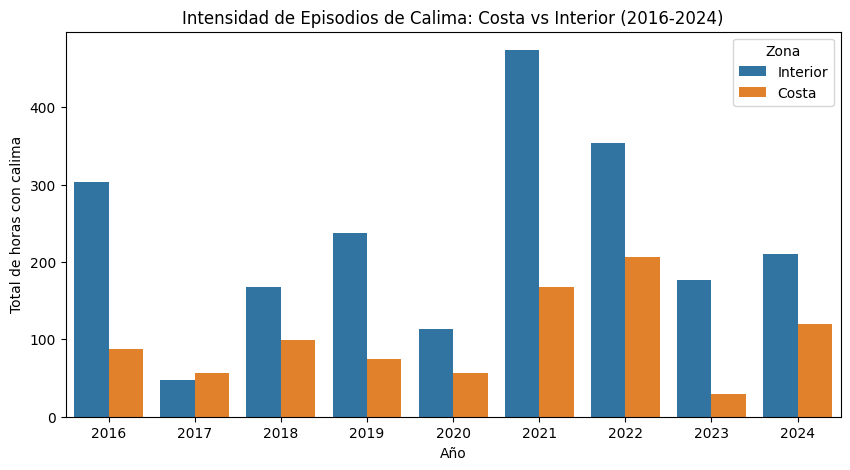

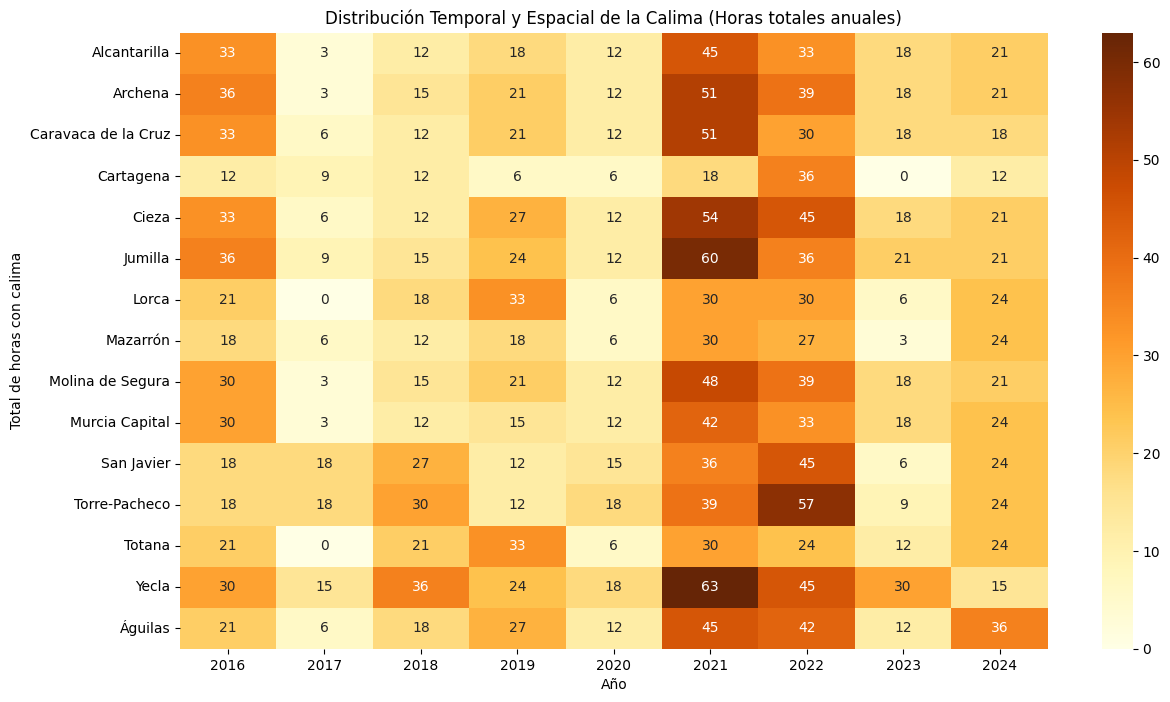

In [35]:
#@title 📊 Visualización de Resultados para el TFM { display-mode: "form" }
# Figura 1: Comparativa
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='anio', y='Horas_Calima', hue='Zona', data=resumen_anual, estimator=sum, errorbar=None)
ax.set(xlabel='Año', ylabel='Total de horas con calima')
plt.title("Intensidad de Episodios de Calima: Costa vs Interior (2016-2024)")
plt.savefig(os.path.join(RUTA_OUTPUT, "Figura_1_Comparativa_Geografica.png"), dpi=300)
plt.show()

# Figura 2: Heatmap
df_pivot = resumen_anual.pivot(index='Estacion', columns='anio', values='Horas_Calima').fillna(0)
plt.figure(figsize=(14, 8))
bx = sns.heatmap(df_pivot, annot=True, cmap="YlOrBr", fmt=".0f")
bx.set(xlabel='Año', ylabel='Total de horas con calima')
plt.title("Distribución Temporal y Espacial de la Calima (Horas totales anuales)")
plt.savefig(os.path.join(RUTA_OUTPUT, "Figura_2_Heatmap_Anual.png"), dpi=300)